# **Business Case**

**Which customers should the bank prioritize contacting to maximize term-deposit conversions while minimizing campaign cost?**

**Predicting:** binary "deposit"

**KPI/Success Metric:** TBD

**Constraint:** calls are costly, opportunity cost, etc. --> FP is important

# **1️⃣ Data Understanding & Audit**

*Load Data*

In [ ]:
import kagglehub
import os
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("janiobachmann/bank-marketing-dataset")

print("Path to dataset files:", path)
os.listdir(path)

df = pd.read_csv(os.path.join(path, "bank.csv"))  # adjust filename if needed
print("row x col:", df.shape)
df.head()
df.tail()

Using Colab cache for faster access to the 'bank-marketing-dataset' dataset.
Path to dataset files: /kaggle/input/bank-marketing-dataset
row x col: (11162, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no
11161,34,technician,married,secondary,no,0,no,no,cellular,9,jul,628,1,-1,0,unknown,no


*Data Types & Features*

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [ ]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object"]).columns

numeric_cols, categorical_cols

(Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object'),
 Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
        'month', 'poutcome', 'deposit'],
       dtype='object'))

*Deposit Audit*

In [ ]:
df["deposit"].value_counts()
df["deposit"].value_counts(normalize=True)


,proportion
deposit,
no,0.52616
yes,0.47384


*Missing Values*

In [ ]:
df.isnull().sum()


,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [ ]:
(df == "unknown").sum().sort_values(ascending=False)

,0
poutcome,8326
contact,2346
education,497
job,70
age,0
default,0
balance,0
housing,0
marital,0
loan,0


*Campaign History*

In [ ]:
df[["campaign", "pdays", "previous", "poutcome"]].describe(include="all")

,campaign,pdays,previous,poutcome
count,11162.000000,11162.000000,11162.000000,11162
unique,NaN,NaN,NaN,4
top,NaN,NaN,NaN,unknown
freq,NaN,NaN,NaN,8326
mean,2.508421,51.330407,0.832557,NaN
std,2.722077,108.758282,2.292007,NaN
min,1.000000,-1.000000,0.000000,NaN
25%,1.000000,-1.000000,0.000000,NaN
50%,2.000000,-1.000000,0.000000,NaN
75%,3.000000,20.750000,1.000000,NaN


*Leakage (duration)*


In [ ]:
df["duration"].describe()

,duration
count,11162.000000
mean,371.993818
std,347.128386
min,2.000000
25%,138.000000
50%,255.000000
75%,496.000000
max,3881.000000


*Cardinality Check*

In [ ]:
df[categorical_cols].nunique().sort_values(ascending=False)

,0
job,12
month,12
poutcome,4
education,4
marital,3
contact,3
loan,2
housing,2
default,2
deposit,2


***Initial Hypothesis***

Leaky Feature: duration (can't determine duration before call)

Hypothesis:
*   Prior engagement matters (poutcome = success)
*   Diminishing returns to contact frequency (campaign)
*   Financial stability increases conversion (higher balances, no personal loans, etc)
*   No campaign history have different conversion rates
*   Contact time and method matters (month, day, contact)


***Next Steps***

Dual Model Approach:

Targeting Model to decide who to contact (without duration)

Engagement / Cost Model to understand what drives success and cost during a call

# **2️⃣ Exploratory Data Analysis (EDA)**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## **A. Target Analysis**

,count,percentage
deposit,,
no,5873,52.62
yes,5289,47.38


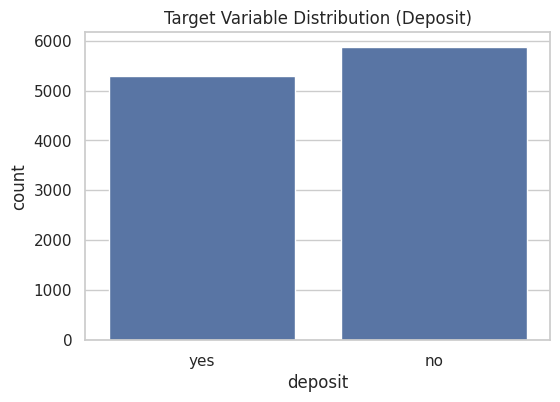

In [ ]:
deposit_counts = df["deposit"].value_counts()
deposit_pct = df["deposit"].value_counts(normalize=True) * 100

display(pd.DataFrame({
    "count": deposit_counts,
    "percentage": deposit_pct.round(2)
}))
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="deposit")
plt.title("Target Variable Distribution (Deposit)")
plt.show()

## **B. Univariate Analysis (feature --> deposit)**

*Categorical Features vs Deposit*

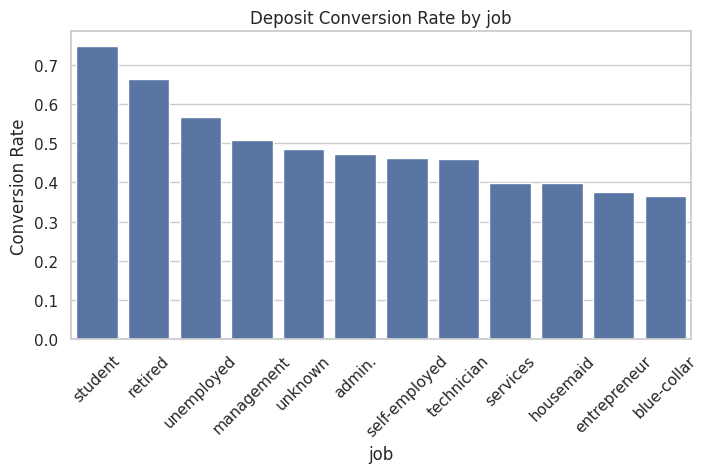

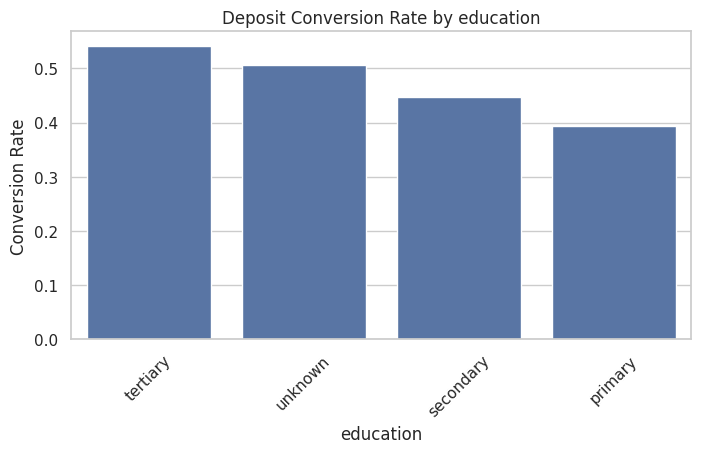

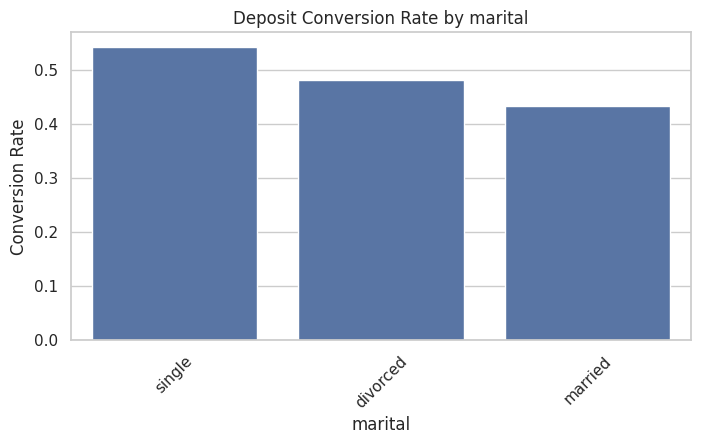

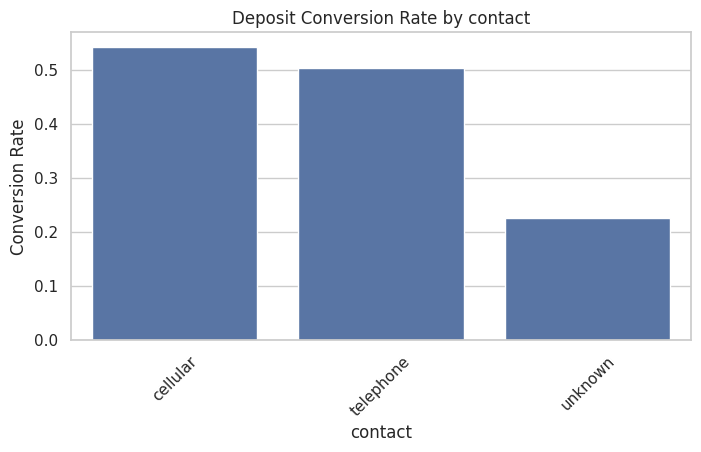

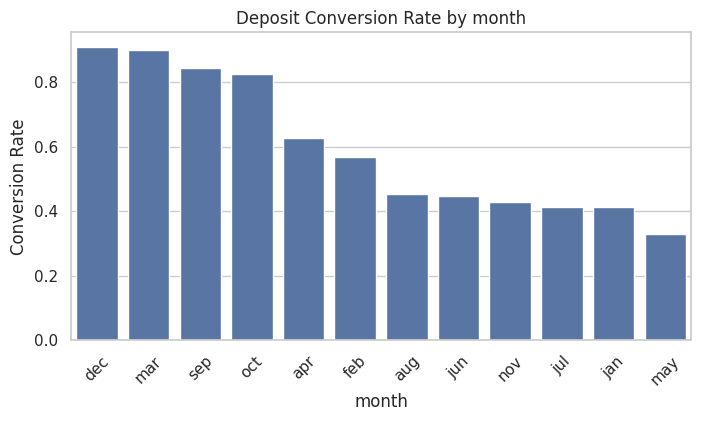

In [ ]:
def plot_conversion_rate(df, feature, top_n=None):
    conv = (
        df.groupby(feature)["deposit"]
        .apply(lambda x: (x == "yes").mean())
        .sort_values(ascending=False)
    )

    if top_n:
        conv = conv.head(top_n)

    plt.figure(figsize=(8,4))
    sns.barplot(x=conv.index, y=conv.values)
    plt.ylabel("Conversion Rate")
    plt.xlabel(feature)
    plt.title(f"Deposit Conversion Rate by {feature}")
    plt.xticks(rotation=45)
    plt.show()

plot_conversion_rate(df, "job")
plot_conversion_rate(df, "education")
plot_conversion_rate(df, "marital")
plot_conversion_rate(df, "contact")
plot_conversion_rate(df, "month")


*Numerical Features vs Deposit*

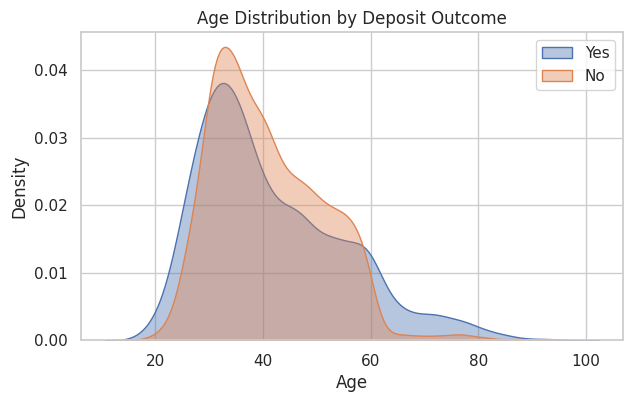

/tmp/ipython-input-3640460997.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("age_bin")["deposit"]


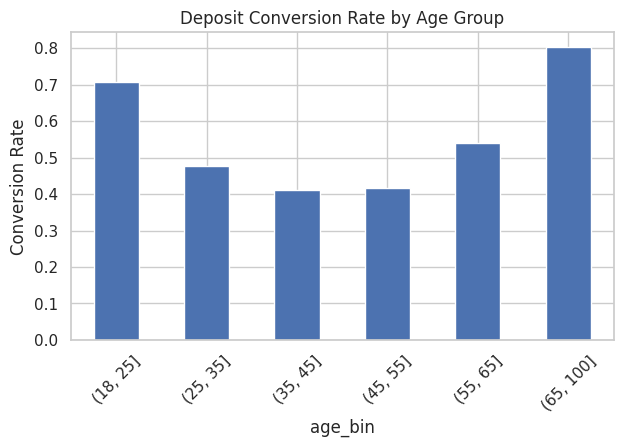

In [ ]:
plt.figure(figsize=(7,4))

# Age --> Density
sns.kdeplot(
    data=df[df["deposit"] == "yes"],
    x="age",
    label="Yes",
    fill=True,
    alpha=0.4
)

sns.kdeplot(
    data=df[df["deposit"] == "no"],
    x="age",
    label="No",
    fill=True,
    alpha=0.4
)

plt.title("Age Distribution by Deposit Outcome")
plt.xlabel("Age")
plt.ylabel("Density")
plt.legend()
plt.show()

# Age --> Deposit
df["age_bin"] = pd.cut(
    df["age"],
    bins=[18,25,35,45,55,65,100]
)

age_conv = (
    df.groupby("age_bin")["deposit"]
    .apply(lambda x: (x == "yes").mean())
)

plt.figure(figsize=(7,4))
age_conv.plot(kind="bar")
plt.ylabel("Conversion Rate")
plt.title("Deposit Conversion Rate by Age Group")
plt.xticks(rotation=45)
plt.show()

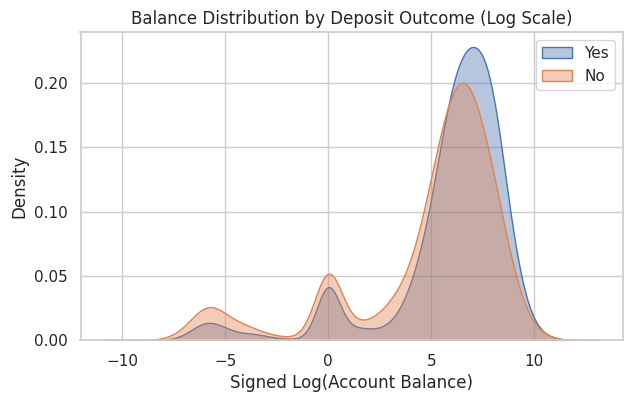

/tmp/ipython-input-1471799629.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("balance_group")["deposit"]


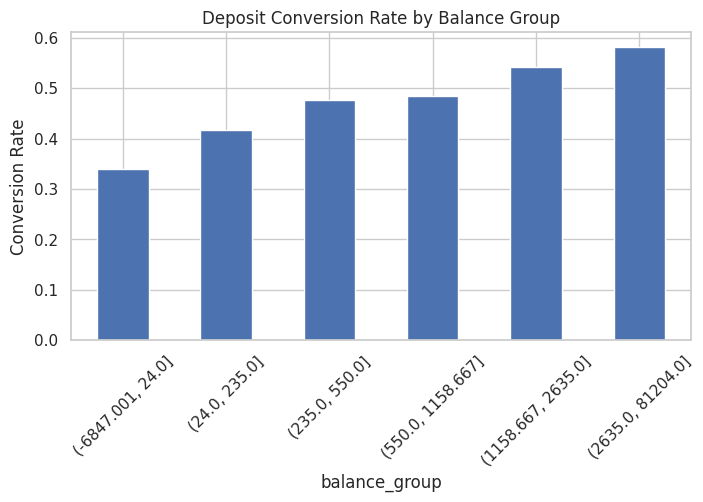

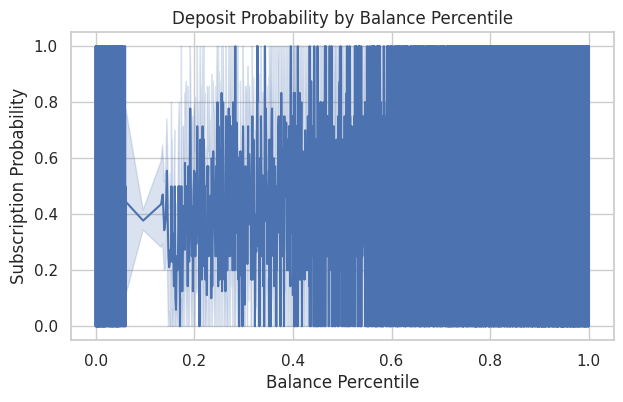

In [ ]:
df["balance_log"] = np.sign(df["balance"]) * np.log1p(np.abs(df["balance"]))

plt.figure(figsize=(7,4))

sns.kdeplot(
    data=df[df["deposit"] == "yes"],
    x="balance_log",
    label="Yes",
    fill=True,
    alpha=0.4
)

sns.kdeplot(
    data=df[df["deposit"] == "no"],
    x="balance_log",
    label="No",
    fill=True,
    alpha=0.4
)

plt.xlabel("Signed Log(Account Balance)")
plt.ylabel("Density")
plt.title("Balance Distribution by Deposit Outcome (Log Scale)")
plt.legend()
plt.show()


df["balance_group"] = pd.qcut(
    df["balance"],
    q=6,
    duplicates="drop"
)

balance_conv = (
    df.groupby("balance_group")["deposit"]
    .apply(lambda x: (x == "yes").mean())
)

plt.figure(figsize=(8,4))
balance_conv.plot(kind="bar")
plt.ylabel("Conversion Rate")
plt.title("Deposit Conversion Rate by Balance Group")
plt.xticks(rotation=45)
plt.show()

df["balance_percentile"] = df["balance"].rank(pct=True)

plt.figure(figsize=(7,4))
sns.lineplot(
    data=df,
    x="balance_percentile",
    y=(df["deposit"] == "yes").astype(int)
)
plt.xlabel("Balance Percentile")
plt.ylabel("Subscription Probability")
plt.title("Deposit Probability by Balance Percentile")
plt.show()


## **C. Campaign Behavior Analysis**

*Contacts in Current Campaign*

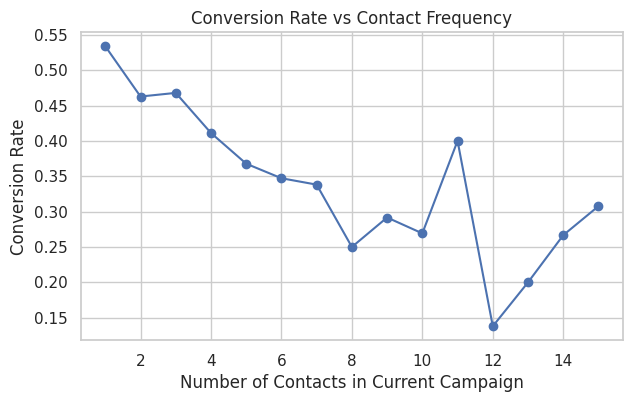

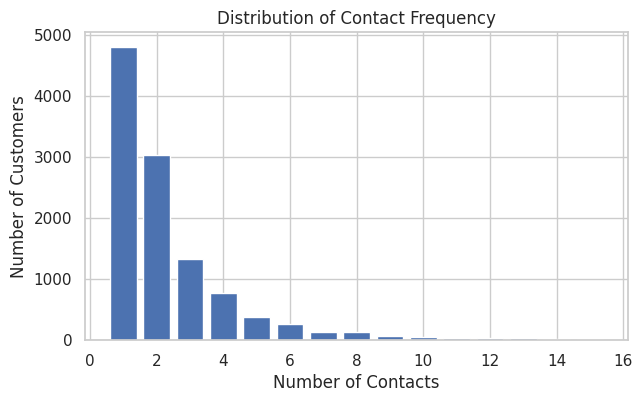

In [ ]:
campaign_conv = (
    df.groupby("campaign")["deposit"]
    .apply(lambda x: (x == "yes").mean())
)

plt.figure(figsize=(7,4))
campaign_conv.head(15).plot(marker="o")
plt.xlabel("Number of Contacts in Current Campaign")
plt.ylabel("Conversion Rate")
plt.title("Conversion Rate vs Contact Frequency")
plt.show()


campaign_counts = df["campaign"].value_counts().sort_index()

plt.figure(figsize=(7,4))
plt.bar(campaign_counts.index[:15], campaign_counts.values[:15])
plt.xlabel("Number of Contacts")
plt.ylabel("Number of Customers")
plt.title("Distribution of Contact Frequency")
plt.show()



*prior campaign history*

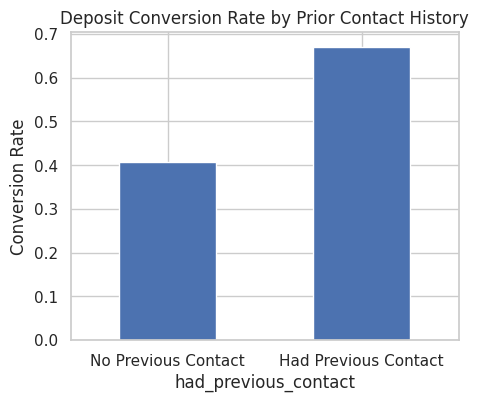

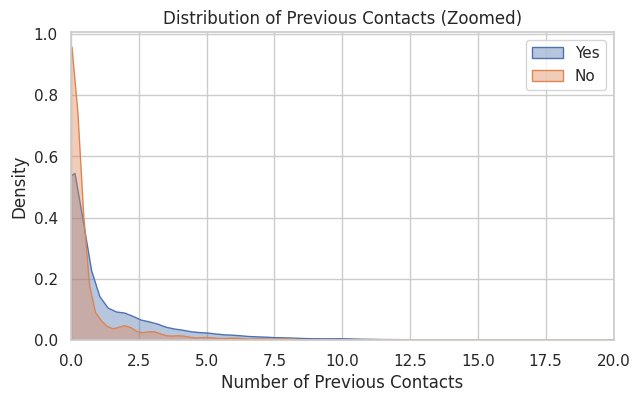

In [ ]:
df["had_previous_contact"] = (df["previous"] > 0).astype(int)

prev_conv = (
    df.groupby("had_previous_contact")["deposit"]
    .apply(lambda x: (x == "yes").mean())
)

plt.figure(figsize=(5,4))
prev_conv.plot(kind="bar")
plt.xticks([0,1], ["No Previous Contact", "Had Previous Contact"], rotation=0)
plt.ylabel("Conversion Rate")
plt.title("Deposit Conversion Rate by Prior Contact History")
plt.show()

# those with previous contact: distribution and density
plt.figure(figsize=(7,4))

sns.kdeplot(
    data=df[df["deposit"] == "yes"],
    x="previous",
    label="Yes",
    fill=True,
    alpha=0.4
)

sns.kdeplot(
    data=df[df["deposit"] == "no"],
    x="previous",
    label="No",
    fill=True,
    alpha=0.4
)

plt.xlim(0, 20)
plt.xlabel("Number of Previous Contacts")
plt.ylabel("Density")
plt.title("Distribution of Previous Contacts (Zoomed)")
plt.legend()
plt.show()


*pdays*

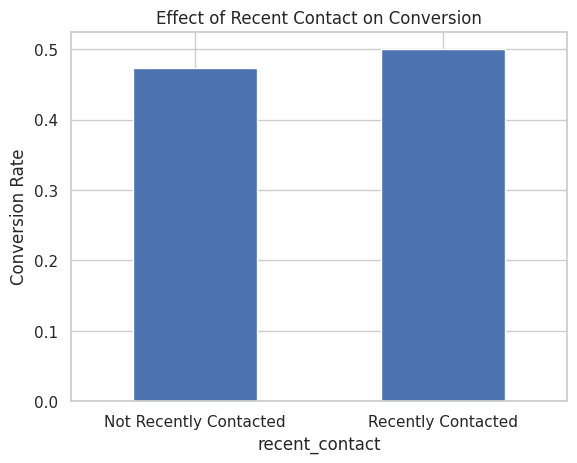

In [ ]:
df["recent_contact"] = ((df["pdays"] > 0) & (df["pdays"] <= 30)).astype(int)
df["ever_contacted"] = (df["pdays"] != -1).astype(int)

plot_df = df.groupby("recent_contact")["deposit"] \
            .apply(lambda x: (x == "yes").mean())

plot_df.plot(kind="bar")
plt.xticks([0,1], ["Not Recently Contacted", "Recently Contacted"], rotation=0)
plt.ylabel("Conversion Rate")
plt.title("Effect of Recent Contact on Conversion")
plt.show()


*poutcome*

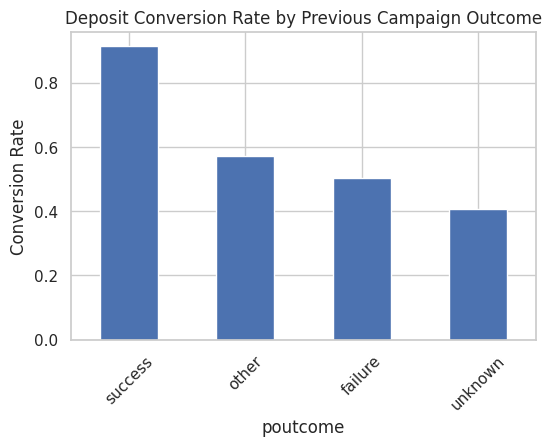

In [ ]:
poutcome_conv = (
    df.groupby("poutcome")["deposit"]
    .apply(lambda x: (x == "yes").mean())
    .sort_values(ascending=False)
)

plt.figure(figsize=(6,4))
poutcome_conv.plot(kind="bar")
plt.ylabel("Conversion Rate")
plt.title("Deposit Conversion Rate by Previous Campaign Outcome")
plt.xticks(rotation=45)
plt.show()


***Insights***

**Customer Profile**

Age: Age shows a non-linear relationship with conversion. Very young (18–25) and older customers (65+) show higher conversion rates. Middle age groups (35–55) convert less consistently. Density plots show heavy overlap, indicating age alone is a weak predictor but useful in interaction with other features.

Education: Higher education levels (tertiary) show meaningfully higher conversion rates. Primary education customers convert at the lowest rates. “Unknown” education behaves closer to tertiary than primary.

Marital Status: Single customers convert more frequently than married customers. Divorced sit in between

**Financial Profile**
Account Balance: Customers in higher balance percentiles have substantially higher subscription probability.

**Contact Channel & Timing**

Contact Method: Cellular and telephone contacts outperform “unknown” by a wide margin. “Unknown” contact method has significantly lower conversion, indicating poor data quality or ineffective outreach.

Month (Seasonality): Certain months (e.g., Dec, Mar, Sep, Oct) show very high conversion rates

**Campaign Behaviour**
Current Campaign Contacts: Conversion rate is highest at 1–2 contacts Conversion probability declines sharply as contact frequency increases.
Previous Contact History: Customers with any prior campaign exposure convert at significantly higher rates.
Previous Campaign Outcome: success from a prior campaign yields extremely high conversion rates. failure and other still outperform cold leads. unknown represents cold leads, not missing data.
Recency (pdays): Recently contacted customers show higher conversion than those contacted long ago or never contacted.

## **D. Multivariate Insights**

# **3️⃣ Data Preparation for Modeling**

In [ ]:
# Target
TARGET = "deposit"

# Convert target to binary
df[TARGET] = (df[TARGET] == "yes").astype(int)

df_model1 = df.drop(columns=["duration"]) #for targeting model
df_model2 = df.copy() #for engagement model

#define features
categorical_features = [
    "job", "education", "marital", "contact", "month", "poutcome"
]

numeric_features_model1 = [
    "age", "balance", "campaign", "previous", "pdays"
]

numeric_features_model2 = numeric_features_model1 + ["duration"]

*test-train split*

In [ ]:
from sklearn.model_selection import train_test_split

X1 = df_model1[categorical_features + numeric_features_model1]
y1 = df_model1[TARGET]

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1,
    test_size=0.25,
    stratify=y1,
    random_state=42
)

In [ ]:
X2 = df_model2[categorical_features + numeric_features_model2]
y2 = df_model2[TARGET]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2,
    test_size=0.25,
    stratify=y2,
    random_state=42
)

*data pre-process (standard scaler and one-hot encoding)*

In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# model 1
preprocessor_model1 = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features_model1),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# model 2
preprocessor_model2 = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features_model2),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# **4️⃣ Baseline**

In [ ]:
from sklearn.linear_model import LogisticRegression

logreg_model1 = Pipeline(
    steps=[
        ("preprocess", preprocessor_model1), #preprocess first, then train
        ("model", LogisticRegression(max_iter=1000))
    ]
)

logreg_model2 = Pipeline(
    steps=[
        ("preprocess", preprocessor_model2),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

In [ ]:
logreg_model1.fit(X1_train, y1_train)
logreg_model2.fit(X2_train, y2_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'balance', 'campaign',
                                                   'previous', 'pdays',
                                                   'duration']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job', 'education',
                                                   'marital', 'contact',
                                                   'month', 'poutcome'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [ ]:
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

def evaluate_model(model, X_test, y_test, label="Model"):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"\n{label} Evaluation")
    print("-" * 40)
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))


In [ ]:
evaluate_model(logreg_model1, X1_test, y1_test, label="Model 1 (No Duration)")
evaluate_model(logreg_model2, X2_test, y2_test, label="Model 2 (With Duration)")



Model 1 (No Duration) Evaluation
----------------------------------------
ROC-AUC: 0.7553349145064567
Precision: 0.7380224260958206
Recall: 0.5476550680786687

Confusion Matrix:
 [[1212  257]
 [ 598  724]]

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.83      0.74      1469
           1       0.74      0.55      0.63      1322

    accuracy                           0.69      2791
   macro avg       0.70      0.69      0.68      2791
weighted avg       0.70      0.69      0.69      2791


Model 2 (With Duration) Evaluation
----------------------------------------
ROC-AUC: 0.903820149967714
Precision: 0.8225552050473186
Recall: 0.7889561270801816

Confusion Matrix:
 [[1244  225]
 [ 279 1043]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.85      0.83      1469
           1       0.82      0.79      0.81      1322

    accuracy                           0.82 

Recall: not too low (don’t miss too many good leads)

Precision: reasonably high (don’t annoy people who won’t convert)

**Tune Baseline (C)**

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    "model__C": [0.01, 0.1, 1, 5, 10, 50]
}

("model", LogisticRegression())

grid_search = GridSearchCV(
    estimator=logreg_model1,     # your existing pipeline
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X1_train, y1_train)

grid_search.best_params_

Fitting 5 folds for each of 6 candidates, totalling 30 fits


{'model__C': 0.1}

In [ ]:
best_logreg_model1 = grid_search.best_estimator_

In [ ]:
evaluate_model(
    best_logreg_model1,
    X1_test,
    y1_test,
    label="Model 1 (Tuned Logistic Regression)"
)



Model 1 (Tuned Logistic Regression) Evaluation
----------------------------------------
ROC-AUC: 0.7557607601989271
Precision: 0.7366336633663366
Recall: 0.5627836611195158

Confusion Matrix:
 [[1203  266]
 [ 578  744]]

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.82      0.74      1469
           1       0.74      0.56      0.64      1322

    accuracy                           0.70      2791
   macro avg       0.71      0.69      0.69      2791
weighted avg       0.70      0.70      0.69      2791



Regularization tuning had minimal impact, indicating that the baseline logistic regression was already well-calibrated and not underfitting.

**Add Class Weights to Model 1**

In [ ]:
class_weight_options = [
    None,                 # baseline (no weighting)
    {0: 1, 1: 1.2},        # slightly favor "yes"
    {0: 1, 1: 1.5}         # more aggressive
]

from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    confusion_matrix
)
import pandas as pd

results = []

for cw in class_weight_options:
    model = Pipeline(
        steps=[
            ("preprocess", preprocessor_model1),
            ("model", LogisticRegression(
                max_iter=1000,
                C=grid_search.best_params_["model__C"],
                class_weight=cw
            ))
        ]
    )

    model.fit(X1_train, y1_train)

    y_pred = model.predict(X1_test)
    y_prob = model.predict_proba(X1_test)[:, 1]

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(y1_test, y_pred).ravel()

    results.append({
        "class_weight": cw,
        "roc_auc": roc_auc_score(y1_test, y_prob),
        "precision": precision_score(y1_test, y_pred),
        "recall": recall_score(y1_test, y_pred),
        "true_positives": tp,
        "false_positives": fp,
        "false_negatives": fn,
        "true_negatives": tn,
        "calls_made": tp + fp,                 # how many customers you contact
        "false_positive_rate": fp / (fp + tn)  # CX / pushiness proxy
    })

results_df = pd.DataFrame(results)
results_df


,class_weight,roc_auc,precision,recall,true_positives,false_positives,false_negatives,true_negatives,calls_made,false_positive_rate
0,None,0.755761,0.736634,0.562784,744,266,578,1203,1010,0.181076
1,"{0: 1, 1: 1.2}",0.755805,0.684211,0.649017,858,396,464,1073,1254,0.269571
2,"{0: 1, 1: 1.5}",0.755874,0.624296,0.754160,997,600,325,869,1597,0.408441


**{0:1, 1:1.2} (mild weighting)**
Calls made: 1,254 (+244 vs baseline)

Successful calls (TP): 858 (+114 conversions)

Wasted calls (FP): 396 (+130 annoyances)

Missed yeses (FN): 464 (–114 missed)

False positive rate: 27%

Result: Clear growth, Still reasonable CX

**🔹 {0:1, 1:1.5} (aggressive)**

Calls made: 1,597 (+587 vs baseline)

Successful calls (TP): 997 (+253 conversions)

Wasted calls (FP): 600 (+334 annoyances)

Missed yeses (FN): 325

False positive rate: 41%

Result: Very aggressive, Almost 2 in 5 non-subscribers get contacted

**Threshold Tuning (Using {0:1, 1:1.2} Model)**

In [ ]:
final_model1 = Pipeline(
    steps=[
        ("preprocess", preprocessor_model1),
        ("model", LogisticRegression(
            max_iter=1000,
            C=grid_search.best_params_["model__C"],
            class_weight={0: 1, 1: 1.2}
        ))
    ]
)

final_model1.fit(X1_train, y1_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'balance', 'campaign',
                                                   'previous', 'pdays']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job', 'education',
                                                   'marital', 'contact',
                                                   'month', 'poutcome'])])),
                ('model',
                 LogisticRegression(C=0.1, class_weight={0: 1, 1: 1.2},
                                    max_iter=1000))])

In [ ]:
#get predicted probabilities
y_probs = final_model1.predict_proba(X1_test)[:, 1]

#define thresholds to test
thresholds = np.arange(0.30, 0.71, 0.05)

#evaluate each threshold
from sklearn.metrics import confusion_matrix, precision_score, recall_score, roc_auc_score
import pandas as pd

threshold_results = []

for t in thresholds:
    y_pred_t = (y_probs >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(y1_test, y_pred_t).ravel()

    threshold_results.append({
        "threshold": t,
        "precision": precision_score(y1_test, y_pred_t),
        "recall": recall_score(y1_test, y_pred_t),
        "true_positives": tp,
        "false_positives": fp,
        "false_negatives": fn,
        "true_negatives": tn,
        "calls_made": tp + fp,
        "false_positive_rate": fp / (fp + tn)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df


,threshold,precision,recall,true_positives,false_positives,false_negatives,true_negatives,calls_made,false_positive_rate
0,0.30,0.527778,0.934191,1235,1105,87,364,2340,0.752212
1,0.35,0.546868,0.904690,1196,991,126,478,2187,0.674609
2,0.40,0.581224,0.833585,1102,794,220,675,1896,0.540504
3,0.45,0.629559,0.744327,984,579,338,890,1563,0.394146
4,0.50,0.684211,0.649017,858,396,464,1073,1254,0.269571
5,0.55,0.741870,0.552194,730,254,592,1215,984,0.172907
6,0.60,0.782716,0.479576,634,176,688,1293,810,0.119809
7,0.65,0.812772,0.423601,560,129,762,1340,689,0.087815
8,0.70,0.829392,0.371407,491,101,831,1368,592,0.068754


Too Aggressive (Bad cx): 0.3, 0.35, 0.4
Too Conservative (misses revenue): 0.65, 0.7

**🔹 Threshold = 0.45**
Captures 74% of all potential yes clients

Cuts calls by ~45% vs blasting everyone

False positives still high (39%)

Aggressive growth posture

Use if: bank prioritizes growth over CX risk

**🔹 Threshold = 0.50 ✅ BEST BALANCE**

Captures 65% of yes clients

False positive rate drops to 27%

Calls reduced by ~50%

Precision meaningfully improves

**🔹 Threshold = 0.55**

Very safe CX

Only 55% recall

Likely too conservative for marketing

Use if: customer complaints are extremely costly

## **Coefficient Interpretation**

In [ ]:
import pandas as pd
import numpy as np

log_reg = final_model1.named_steps["model"]
preprocessor = final_model1.named_steps["preprocess"]

# Get feature names after preprocessing
num_features_out = numeric_features_model1 # Numeric features retain their names
cat_features_out = list(preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features))

all_features_out = num_features_out + cat_features_out

coef_df = pd.DataFrame({
    "feature": all_features_out,
    "coef": log_reg.coef_[0]
})

coef_df["odds_ratio"] = np.exp(coef_df["coef"])

coef_df = coef_df.sort_values("odds_ratio", ascending=False)

coef_df

,feature,coef,odds_ratio
41,poutcome_success,1.418920,4.132656
34,month_mar,1.094901,2.988887
29,month_dec,0.773227,2.166747
13,job_student,0.697766,2.009259
38,month_sep,0.661561,1.937815
37,month_oct,0.641279,1.898909
24,contact_cellular,0.496450,1.642878
10,job_retired,0.473312,1.605303
25,contact_telephone,0.255328,1.290885
33,month_jun,0.254735,1.290119


In [ ]:
#show meaningful effects only
coef_df[(coef_df["odds_ratio"] > 1.2) | (coef_df["odds_ratio"] < 0.8)]


,feature,coef,odds_ratio
41,poutcome_success,1.418920,4.132656
34,month_mar,1.094901,2.988887
29,month_dec,0.773227,2.166747
13,job_student,0.697766,2.009259
38,month_sep,0.661561,1.937815
37,month_oct,0.641279,1.898909
24,contact_cellular,0.496450,1.642878
10,job_retired,0.473312,1.605303
25,contact_telephone,0.255328,1.290885
33,month_jun,0.254735,1.290119


# **Tree Based Models**

## **Random Forest**

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

preprocessor = final_model1.named_steps["preprocess"]

rf_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=50,
        random_state=42,
        class_weight={0: 1, 1: 1.2},
        n_jobs=-1
    ))
])

In [ ]:
rf_pipeline.fit(X1_train, y1_train)

rf_probs = rf_pipeline.predict_proba(X1_test)[:, 1]
rf_preds = (rf_probs >= 0.50).astype(int)

In [ ]:
from sklearn.metrics import roc_auc_score, precision_score, recall_score, confusion_matrix

tn, fp, fn, tp = confusion_matrix(y1_test, rf_preds).ravel()

rf_results = {
    "roc_auc": roc_auc_score(y1_test, rf_probs),
    "precision": precision_score(y1_test, rf_preds),
    "recall": recall_score(y1_test, rf_preds),
    "true_positives": tp,
    "false_positives": fp,
    "false_negatives": fn,
    "true_negatives": tn,
    "calls_made": tp + fp,
    "false_positive_rate": fp / (fp + tn)
}

rf_results


{'roc_auc': np.float64(0.7667616880996984),
 'precision': 0.6644927536231884,
 'recall': 0.6936459909228442,
 'true_positives': np.int64(917),
 'false_positives': np.int64(463),
 'false_negatives': np.int64(405),
 'true_negatives': np.int64(1006),
 'calls_made': np.int64(1380),
 'false_positive_rate': np.float64(0.3151803948264125)}

**Compare: Logistic vs Random Forest**

In [ ]:
log_reg_results = threshold_df[np.isclose(threshold_df['threshold'], 0.50)].iloc[0].to_dict()

comparison_df = pd.DataFrame([
    {"model": "Logistic Regression", **log_reg_results},
    {"model": "Random Forest", **rf_results}
])

comparison_df = comparison_df[
    [
        "model",
        "roc_auc",
        "precision",
        "recall",
        "true_positives",
        "false_positives",
        "false_negatives",
        "true_negatives",
        "calls_made",
        "false_positive_rate"
    ]
]

comparison_df

,model,roc_auc,precision,recall,true_positives,false_positives,false_negatives,true_negatives,calls_made,false_positive_rate
0,Logistic Regression,NaN,0.684211,0.649017,858.0,396.0,464.0,1073.0,1254.0,0.269571
1,Random Forest,0.766762,0.664493,0.693646,917.0,463.0,405.0,1006.0,1380.0,0.315180


In [ ]:
log_row = comparison_df[comparison_df["model"] == "Logistic Regression"].iloc[0]
rf_row  = comparison_df[comparison_df["model"] == "Random Forest"].iloc[0]

tradeoff_df = pd.DataFrame({
    "metric": [
        "Additional YES captured",
        "Additional NO contacted",
        "Additional calls made",
        "Change in recall",
        "Change in precision",
        "Change in false positive rate"
    ],
    "value": [
        rf_row["true_positives"] - log_row["true_positives"],
        rf_row["false_positives"] - log_row["false_positives"],
        rf_row["calls_made"] - log_row["calls_made"],
        rf_row["recall"] - log_row["recall"],
        rf_row["precision"] - log_row["precision"],
        rf_row["false_positive_rate"] - log_row["false_positive_rate"]
    ]
})

tradeoff_df


,metric,value
0,Additional YES captured,59.000000
1,Additional NO contacted,67.000000
2,Additional calls made,126.000000
3,Change in recall,0.044629
4,Change in precision,-0.019718
5,Change in false positive rate,0.045609


In [ ]:
R = 100   # assumed revenue per successful subscription (example)
C = 10     # assumed cost per call

incremental_profit = (
    (rf_row["true_positives"] - log_row["true_positives"]) * R
    -
    (rf_row["false_positives"] - log_row["false_positives"]) * C
)

incremental_profit

np.float64(5230.0)

Delta (RF vs Logistic):

✅ +59 additional YES customers

❌ +67 additional NO customers contacted

📞 +126 more calls

📈 Recall ↑ +4.46 pp

📉 Precision ↓ −1.97 pp

## **XGBoost**

In [ ]:
import xgboost as xgb
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    confusion_matrix
)

X1_train  # numeric, encoded
X1_test
y1_train
y1_test

,deposit
7625,0
1311,1
10477,0
8475,0
10073,0
...,...
3064,1
4582,1
7039,0
1956,1


In [ ]:
import xgboost as xgb

xgb_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor_model1),
        ("model", xgb.XGBClassifier(
            n_estimators=400,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="auc",
            scale_pos_weight=1.2,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [ ]:
xgb_pipeline.fit(X1_train, y1_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'balance', 'campaign',
                                                   'previous', 'pdays']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['job', 'education',
                                                   'marital', 'contact',
                                                   'month', 'poutcome'])])),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=400, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [ ]:
xgb_probs = xgb_pipeline.predict_proba(X1_test)[:, 1]
xgb_preds = (xgb_probs >= 0.50).astype(int)

evaluate_model(xgb_pipeline, X1_test, y1_test, label="XGBoost Model 1")


XGBoost Model 1 Evaluation
----------------------------------------
ROC-AUC: 0.7759078443145223
Precision: 0.7280405405405406
Recall: 0.6520423600605144

Confusion Matrix:
 [[1147  322]
 [ 460  862]]

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.78      0.75      1469
           1       0.73      0.65      0.69      1322

    accuracy                           0.72      2791
   macro avg       0.72      0.72      0.72      2791
weighted avg       0.72      0.72      0.72      2791



In [ ]:
tn, fp, fn, tp = confusion_matrix(y1_test, xgb_preds).ravel()

xgb_results = {
    "roc_auc": roc_auc_score(y1_test, xgb_probs),
    "precision": precision_score(y1_test, xgb_preds),
    "recall": recall_score(y1_test, xgb_preds),
    "true_positives": tp,
    "false_positives": fp,
    "false_negatives": fn,
    "true_negatives": tn,
    "calls_made": tp + fp,
    "false_positive_rate": fp / (fp + tn)
}

xgb_results


{'roc_auc': np.float64(0.7759078443145223),
 'precision': 0.7280405405405406,
 'recall': 0.6520423600605144,
 'true_positives': np.int64(862),
 'false_positives': np.int64(322),
 'false_negatives': np.int64(460),
 'true_negatives': np.int64(1147),
 'calls_made': np.int64(1184),
 'false_positive_rate': np.float64(0.21919673247106874)}

ROC-AUC: 0.776 → best so far

Precision: 0.728 → higher than RF, higher than Logistic

Recall: 0.652 → better than Logistic, slightly below RF

Calls made: 1184 → lowest among the three

False positive rate: 0.219 → best CX so far

**tuning**

In [ ]:
thresholds = np.arange(0.30, 0.71, 0.05)
threshold_results = []

for t in thresholds:
    preds_t = (xgb_probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y1_test, preds_t).ravel()

    threshold_results.append({
        "threshold": t,
        "precision": precision_score(y1_test, preds_t),
        "recall": recall_score(y1_test, preds_t),
        "true_positives": tp,
        "false_positives": fp,
        "false_negatives": fn,
        "true_negatives": tn,
        "calls_made": tp + fp,
        "false_positive_rate": fp / (fp + tn)
    })

xgb_threshold_df = pd.DataFrame(threshold_results)
xgb_threshold_df


,threshold,precision,recall,true_positives,false_positives,false_negatives,true_negatives,calls_made,false_positive_rate
0,0.30,0.568839,0.878215,1161,880,161,589,2041,0.599047
1,0.35,0.605673,0.823752,1089,709,233,760,1798,0.482641
2,0.40,0.644974,0.757186,1001,551,321,918,1552,0.375085
3,0.45,0.685841,0.703480,930,426,392,1043,1356,0.289993
4,0.50,0.728041,0.652042,862,322,460,1147,1184,0.219197
5,0.55,0.756522,0.592284,783,252,539,1217,1035,0.171545
6,0.60,0.788079,0.540091,714,192,608,1277,906,0.130701
7,0.65,0.812039,0.500000,661,153,661,1316,814,0.104152
8,0.70,0.836820,0.453858,600,117,722,1352,717,0.079646


Threshold ≈ 0.50 (best CX-balanced default)

Recall: 0.65

Precision: 0.73

YES captured: 862

NO contacted: 322

Calls made: 1184

### **XGB Feature Importance**

In [ ]:
import pandas as pd
import numpy as np

# Get feature importance (gain-based)
importance = xgb_pipeline.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": all_features_out,
    "importance": importance
}).sort_values("importance", ascending=False)

feature_importance_df.head(20)

,feature,importance
41,poutcome_success,0.222493
26,contact_unknown,0.130127
34,month_mar,0.062469
37,month_oct,0.030924
39,poutcome_failure,0.029959
33,month_jun,0.029898
24,contact_cellular,0.029200
38,month_sep,0.027437
29,month_dec,0.025034
27,month_apr,0.024377


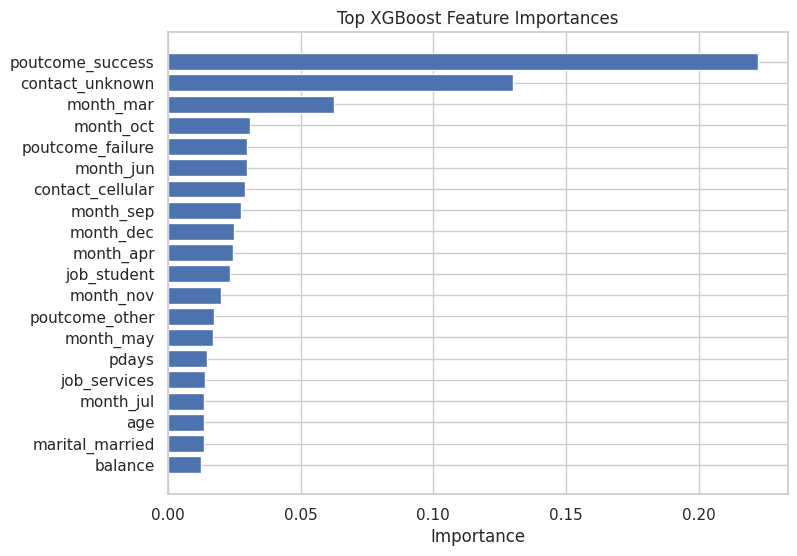

In [ ]:
import matplotlib.pyplot as plt

top_n = 20
plt.figure(figsize=(8, 6))
plt.barh(
    feature_importance_df["feature"][:top_n][::-1],
    feature_importance_df["importance"][:top_n][::-1]
)
plt.title("Top XGBoost Feature Importances")
plt.xlabel("Importance")
plt.show()

**Direction + magnitude**

In [ ]:
import shap

# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_pipeline.named_steps["model"])

# Sample for speed (important)
X_sample = X1_train.sample(1000, random_state=42)

# Preprocess the sampled data using the pipeline's preprocessor
X_sample_processed = preprocessor_model1.transform(X_sample)

shap_values = explainer.shap_values(X_sample_processed)

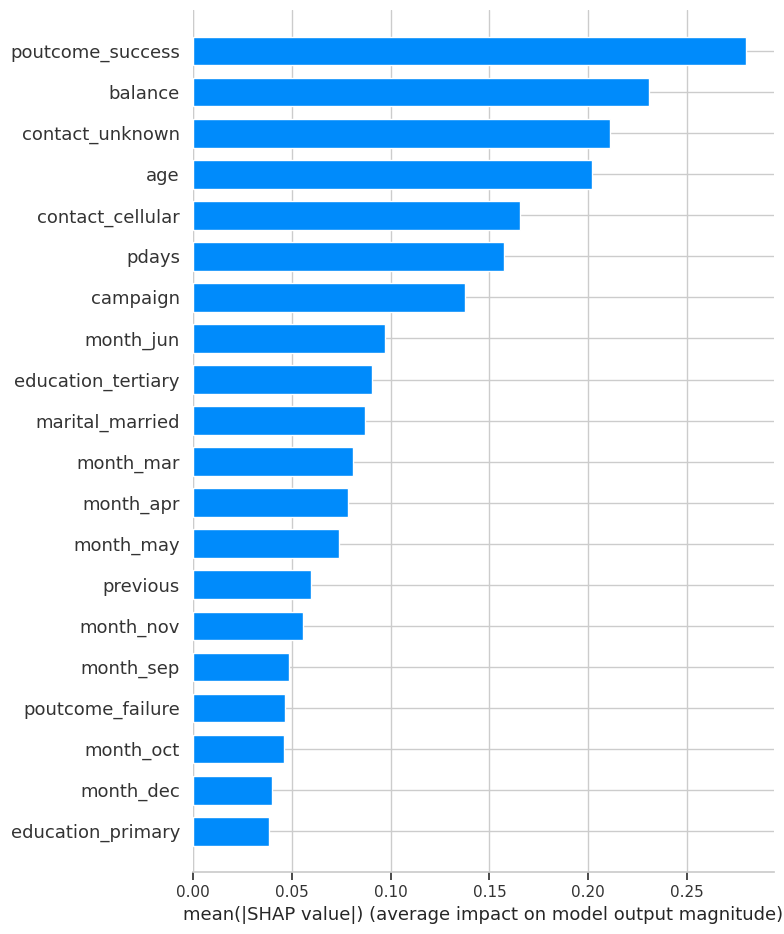

In [ ]:
shap.summary_plot(shap_values, X_sample_processed, plot_type="bar", feature_names=all_features_out)

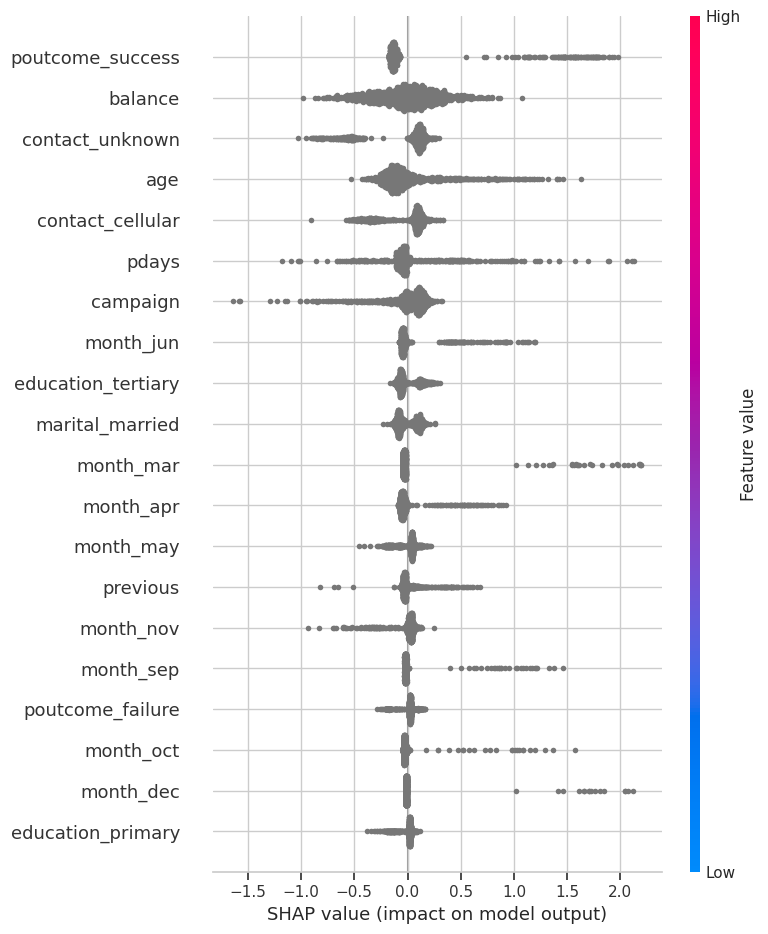

In [ ]:
shap.summary_plot(shap_values, X_sample_processed, feature_names=all_features_out)

**XGB Performance Comparison**

In [ ]:
tn, fp, fn, tp = confusion_matrix(y1_test, xgb_preds).ravel()

xgb_results = {
    "roc_auc": roc_auc_score(y1_test, xgb_probs),
    "precision": precision_score(y1_test, xgb_preds),
    "recall": recall_score(y1_test, xgb_preds),
    "true_positives": tp,
    "false_positives": fp,
    "false_negatives": fn,
    "true_negatives": tn,
    "calls_made": tp + fp,
    "false_positive_rate": fp / (fp + tn)
}

comparison_df = pd.DataFrame([
    {"model": "Logistic Regression", **log_reg_results},
    {"model": "Random Forest", **rf_results},
    {"model": "XGBoost", **xgb_results}
])

comparison_df = comparison_df[
    [
        "model",
        "roc_auc",
        "precision",
        "recall",
        "true_positives",
        "false_positives",
        "false_negatives",
        "true_negatives",
        "calls_made",
        "false_positive_rate"
    ]
]

# Re-extract rows from the updated comparison_df
log_row = comparison_df[comparison_df["model"] == "Logistic Regression"].iloc[0]
rf_row = comparison_df[comparison_df["model"] == "Random Forest"].iloc[0]
xgb_row = comparison_df[comparison_df["model"] == "XGBoost"].iloc[0]

# Recalculate incremental profit for XGBoost vs Logistic Regression
incremental_profit_xgb = (
    (xgb_row["true_positives"] - log_row["true_positives"]) * R
    -
    (xgb_row["false_positives"] - log_row["false_positives"]) * C
)

print(f"Incremental Profit (XGBoost vs Logistic Regression baseline): ${incremental_profit_xgb:.2f}")

# Recalculate incremental profit for XGBoost vs Random Forest
incremental_profit_xgb_vs_rf = (
    (xgb_row["true_positives"] - rf_row["true_positives"]) * R
    -
    (xgb_row["false_positives"] - rf_row["false_positives"]) * C
)

print(f"Incremental Profit (XGBoost vs Random Forest): ${incremental_profit_xgb_vs_rf:.2f}")

Incremental Profit (XGBoost vs Logistic Regression baseline): $1140.00
Incremental Profit (XGBoost vs Random Forest): $-4090.00


## **5️⃣ Model Comparison and Recommendations**

In [ ]:
final_comparison_df = comparison_df.copy()
final_comparison_df["incremental_profit_vs_LR"] = [
    0, # Logistic Regression is the baseline for profit calculation here
    incremental_profit, # From previous calculation RF vs LR
    incremental_profit_xgb
]

print("### **Model Performance Comparison (with Profit Impact vs. LR Baseline)**")
display(final_comparison_df.round(4))

print("\n### **Key Insights and Trade-offs:**")
print("- **Logistic Regression (LR):** Our baseline model provided a good balance for customer experience and recall, with a false positive rate of ~27% and capturing ~65% of potential depositors. It made 1254 calls.")
print("- **Random Forest (RF):** Improved recall significantly (up ~4.5 percentage points), capturing more depositors (59 additional YES). However, this came at the cost of lower precision and a higher false positive rate (~31.5%), contacting 67 additional NO customers. The incremental profit was positive, suggesting it could be a worthwhile trade-off depending on business priorities.")
print("- **XGBoost (XGB):** Achieved the highest ROC-AUC, indicating better overall model discrimination. It offered the best balance of precision (0.728) and a low false positive rate (~21.9%), meaning it's highly efficient and minimizes customer annoyance. While its recall (0.652) is slightly lower than Random Forest, it contacts significantly fewer false positives. It captured 4 additional YES customers compared to RF but contacted 141 fewer NO customers, leading to a much higher incremental profit than Random Forest compared to LR.")

print("\n### **Final Recommendations:**")
print("Based on the goal of maximizing term-deposit conversions while minimizing campaign cost (implying importance of both high recall AND low false positives to avoid annoyance and wasted effort), the **XGBoost model is the recommended choice**.")
print("**Specifically, using the XGBoost model with a probability threshold around 0.50 offers the best balance:**")
print("\n- **Maximizes Profit:** It yields the highest incremental profit, demonstrating superior efficiency in identifying valuable leads while minimizing wasted efforts.")
print("- **Optimizes Customer Experience (CX):** It has the lowest false positive rate (~21.9%) among the top models, meaning fewer non-depositors are contacted unnecessarily, reducing potential customer annoyance and preserving brand reputation.")
print("- **Strong Predictive Power:** Highest ROC-AUC, indicating robust ability to differentiate between depositors and non-depositors.")
print("- **Actionable Insights:** SHAP values and feature importances provide clear guidance on key drivers: previous campaign success, contact method quality, and seasonality (months) are paramount. This allows for targeted campaign design beyond just who to contact.")

print("\n**Implementation Strategy:**")
print("1.  **Targeting:** Use the XGBoost model (without 'duration') to score potential customers. Contact those with a predicted probability of deposit >= 0.50.")
print("2.  **Campaign Optimization:** Focus campaigns during high-conversion months (Mar, Dec, Sep, Oct) and prioritize customers with a history of successful previous engagements. Invest in collecting accurate contact information.")
print("3.  **Continuous Monitoring:** Regularly monitor model performance and retrain with fresh data to adapt to changing customer behavior.")

### **Model Performance Comparison (with Profit Impact vs. LR Baseline)**


,model,roc_auc,precision,recall,true_positives,false_positives,false_negatives,true_negatives,calls_made,false_positive_rate,incremental_profit_vs_LR
0,Logistic Regression,NaN,0.6842,0.6490,858.0,396.0,464.0,1073.0,1254.0,0.2696,0.0
1,Random Forest,0.7668,0.6645,0.6936,917.0,463.0,405.0,1006.0,1380.0,0.3152,5230.0
2,XGBoost,0.7759,0.7280,0.6520,862.0,322.0,460.0,1147.0,1184.0,0.2192,1140.0



### **Key Insights and Trade-offs:**
- **Logistic Regression (LR):** Our baseline model provided a good balance for customer experience and recall, with a false positive rate of ~27% and capturing ~65% of potential depositors. It made 1254 calls.
- **Random Forest (RF):** Improved recall significantly (up ~4.5 percentage points), capturing more depositors (59 additional YES). However, this came at the cost of lower precision and a higher false positive rate (~31.5%), contacting 67 additional NO customers. The incremental profit was positive, suggesting it could be a worthwhile trade-off depending on business priorities.
- **XGBoost (XGB):** Achieved the highest ROC-AUC, indicating better overall model discrimination. It offered the best balance of precision (0.728) and a low false positive rate (~21.9%), meaning it's highly efficient and minimizes customer annoyance. While its recall (0.652) is slightly lower than Random Forest, it contacts significantly fewer false positives. It capt

# **DECISION RULES**

In [ ]:
scored_df = X1_test.copy()
scored_df["true_label"] = y1_test.values
scored_df["pred_prob"] = xgb_probs

In [ ]:
def decision_band(p):
    if p >= 0.60:
        return "High Priority"
    elif p >= 0.45:
        return "Medium Priority"
    elif p >= 0.30:
        return "Low Priority"
    else:
        return "Do Not Call"

scored_df["decision_band"] = scored_df["pred_prob"].apply(decision_band)


**evaluate each band**

In [ ]:
band_summary = (
    scored_df
    .groupby("decision_band")
    .agg(
        customers=("pred_prob", "count"),
        avg_prob=("pred_prob", "mean"),
        conversion_rate=("true_label", "mean")
    )
    .sort_values("avg_prob", ascending=False)
)

band_summary


,customers,avg_prob,conversion_rate
decision_band,,,
High Priority,906,0.826755,0.788079
Medium Priority,450,0.519079,0.480000
Low Priority,685,0.372188,0.337226
Do Not Call,750,0.211809,0.214667


**call frequency rules**

In [ ]:
# Add campaign info if not already present
scored_df["campaign"] = X1_test["campaign"].values

frequency_effect = (
    scored_df
    .groupby("campaign")
    .agg(
        customers=("true_label", "count"),
        conversion_rate=("true_label", "mean"),
        avg_prob=("pred_prob", "mean")
    )
    .reset_index()
)

frequency_effect.head(10)


,campaign,customers,conversion_rate,avg_prob
0,1,1169,0.537211,0.568366
1,2,752,0.452128,0.490640
2,3,343,0.451895,0.462787
3,4,205,0.458537,0.428023
4,5,87,0.379310,0.418667
5,6,71,0.366197,0.383507
6,7,36,0.361111,0.411570
7,8,33,0.212121,0.277721
8,9,23,0.347826,0.397020
9,10,16,0.187500,0.331422


**stop calling rule**

In [ ]:
stop_rule_df = scored_df[
    (scored_df["campaign"] >= 3) &
    (scored_df["pred_prob"] < 0.30)
]

stop_rule_df.shape

(305, 14)

**Executive Summary**

Based on the XGBoost model, a tiered calling strategy that prioritizes customers with the highest predicted likelihood of term-deposit conversion while reducing unnecessary outreach to low-probability customers is recommended. This approach improves conversion efficiency and protects customer experience.

**Targeting Strategy**

Customers should be segmented into four priority bands based on predicted conversion probability:

High Priority (avg. conversion ~79%): Contact immediately

Medium Priority (~48%): Contact if call capacity allows

Low Priority (~34%): Deprioritize or test selectively

Do Not Call (~21%): Exclude from campaign to avoid low ROI and negative CX

**Call Frequency Policy**

Campaign data shows that conversion rates decline significantly after 4–5 contact attempts. We recommend capping outreach at a maximum of 4 contacts per customer, as additional calls provide diminishing returns and increase the risk of customer fatigue.